# Step 2: Molecular Representation & Feature Engineering

Using RDKit, compute molecular descriptors and Morgan fingerprints for each compound.

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Lipinski
from rdkit import DataStructs
import warnings
warnings.filterwarnings('ignore')

# Load data from Step 1
df = pd.read_csv('../data/raw/egfr_bioactivity.csv')
print(f"Loaded {len(df)} compounds")

Loaded 10413 compounds


## 2.1 Generate RDKit Mol Objects

In [2]:
# Convert SMILES to RDKit Mol objects
df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)

# Remove entries where SMILES couldn't be parsed
invalid_count = df['mol'].isna().sum()
print(f"Invalid SMILES: {invalid_count}")
df = df.dropna(subset=['mol']).reset_index(drop=True)
print(f"Valid compounds: {len(df)}")

Invalid SMILES: 0


Valid compounds: 10413


## 2.2 Compute Physicochemical Descriptors

In [3]:
def compute_descriptors(mol):
    """Compute key physicochemical descriptors for a molecule."""
    return {
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'HBA': Descriptors.NumHAcceptors(mol),
        'HBD': Descriptors.NumHDonors(mol),
        'TPSA': Descriptors.TPSA(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol),
        'AromaticRings': Descriptors.NumAromaticRings(mol),
        'HeavyAtoms': Descriptors.HeavyAtomCount(mol),
        'RingCount': Descriptors.RingCount(mol),
        'FractionCSP3': Descriptors.FractionCSP3(mol),
        'NumHeteroatoms': Descriptors.NumHeteroatoms(mol),
        'MolRefractivity': Descriptors.MolMR(mol),
    }

# Compute descriptors for all molecules
desc_list = [compute_descriptors(mol) for mol in df['mol']]
desc_df = pd.DataFrame(desc_list)
print(f"Computed {len(desc_df.columns)} descriptors for {len(desc_df)} compounds")
desc_df.describe().round(2)

Computed 12 descriptors for 10413 compounds


,MW,LogP,HBA,HBD,TPSA,RotBonds,AromaticRings,HeavyAtoms,RingCount,FractionCSP3,NumHeteroatoms,MolRefractivity
count,10413.00,10413.00,10413.00,10413.00,10413.00,10413.00,10413.00,10413.00,10413.00,10413.00,10413.00,10413.00
mean,482.64,4.57,6.74,2.21,96.31,6.94,3.56,34.01,4.44,0.24,9.35,131.70
std,126.12,1.44,2.22,1.30,34.16,3.48,0.92,9.02,1.29,0.13,3.01,33.77
min,110.11,-7.51,0.00,0.00,0.00,0.00,0.00,3.00,0.00,0.00,1.00,0.00
25%,400.49,3.65,5.00,1.00,76.83,5.00,3.00,28.00,4.00,0.14,7.00,109.48
50%,480.37,4.52,7.00,2.00,96.34,7.00,4.00,34.00,4.00,0.24,9.00,130.63
75%,554.57,5.46,8.00,3.00,111.61,9.00,4.00,39.00,5.00,0.32,11.00,152.29
max,3688.83,13.03,45.00,53.00,1465.46,124.00,9.00,261.00,12.00,1.00,90.00,961.88


## 2.3 Compute Morgan Fingerprints

In [4]:
def mol_to_morgan_fp(mol, radius=2, n_bits=2048):
    """Convert molecule to Morgan fingerprint bit vector."""
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros(n_bits, dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# Compute Morgan fingerprints (radius 2, 2048 bits)
fp_array = np.array([mol_to_morgan_fp(mol) for mol in df['mol']])
fp_df = pd.DataFrame(fp_array, columns=[f'FP_{i}' for i in range(fp_array.shape[1])])

print(f"Morgan fingerprints shape: {fp_df.shape}")
print(f"Average bits set per compound: {fp_array.sum(axis=1).mean():.1f}")

[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerat

[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerat

[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerat

[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerator
[23:36:26] DEPRECATION WARNING: please use MorganGenerat

Morgan fingerprints shape: (10413, 2048)
Average bits set per compound: 62.2


## 2.4 Combine Features

In [5]:
# Combine descriptors and fingerprints
features_df = pd.concat([desc_df, fp_df], axis=1)
print(f"Combined feature matrix: {features_df.shape}")

# Check for any NaN/Inf values
nan_cols = features_df.columns[features_df.isna().any()].tolist()
if nan_cols:
    print(f"Columns with NaN: {nan_cols}")
    features_df = features_df.fillna(0)

# Replace any infinite values
features_df = features_df.replace([np.inf, -np.inf], 0)
print(f"Final feature matrix: {features_df.shape} (no NaN/Inf)")

Combined feature matrix: (10413, 2060)


Final feature matrix: (10413, 2060) (no NaN/Inf)


## 2.5 Visualize Descriptor Distributions

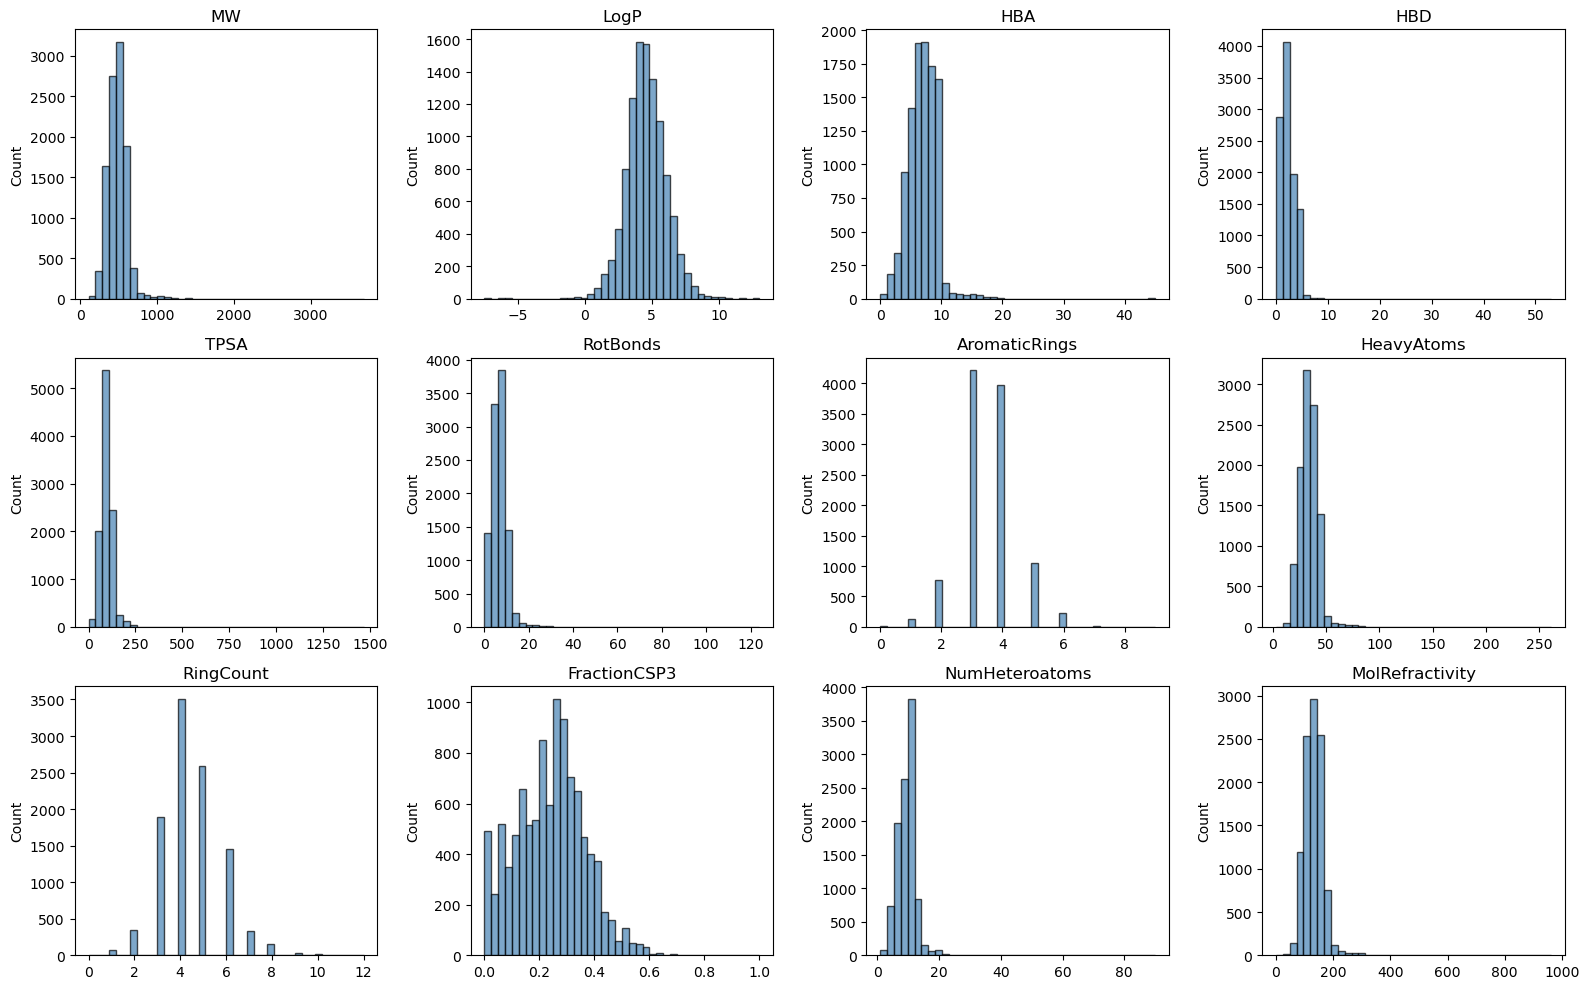

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

descriptor_cols = desc_df.columns.tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(descriptor_cols):
    axes[i].hist(desc_df[col], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/processed/descriptor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation of descriptors with pChEMBL value:
HBA                0.253990
MW                 0.233917
MolRefractivity    0.233170
RingCount          0.226125
HeavyAtoms         0.224621
NumHeteroatoms     0.223244
LogP               0.196773
HBD                0.176633
RotBonds           0.174030
FractionCSP3       0.154591
AromaticRings      0.148097
TPSA               0.084947


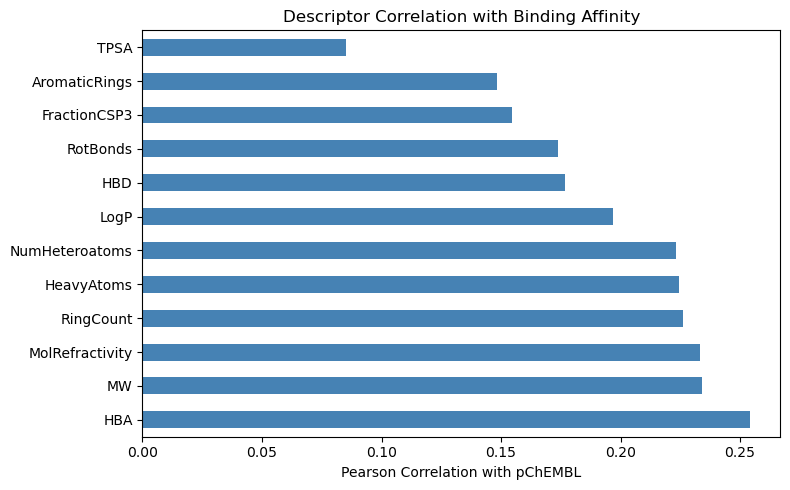

In [7]:
# Correlation between descriptors and pChEMBL
corr_data = desc_df.copy()
corr_data['pchembl_value'] = df['pchembl_value'].values

correlations = corr_data.corr()['pchembl_value'].drop('pchembl_value').sort_values(ascending=False)
print("Correlation of descriptors with pChEMBL value:")
print(correlations.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
correlations.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Pearson Correlation with pChEMBL')
ax.set_title('Descriptor Correlation with Binding Affinity')
plt.tight_layout()
plt.savefig('../data/processed/descriptor_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.6 Save Processed Data

In [8]:
# Save features and target
features_df.to_csv('../data/processed/features.csv', index=False)

# Save target values
target_df = df[['canonical_smiles', 'molecule_chembl_id', 'pchembl_value']].copy()
target_df.to_csv('../data/processed/target.csv', index=False)

# Also save descriptors only (for interpretation)
desc_df.to_csv('../data/processed/descriptors_only.csv', index=False)

print(f"Saved features: {features_df.shape}")
print(f"Saved target: {target_df.shape}")
print(f"\nFeature breakdown:")
print(f"  Physicochemical descriptors: {len(descriptor_cols)}")
print(f"  Morgan fingerprint bits: {fp_df.shape[1]}")
print(f"  Total features: {features_df.shape[1]}")

Saved features: (10413, 2060)
Saved target: (10413, 3)

Feature breakdown:
  Physicochemical descriptors: 12
  Morgan fingerprint bits: 2048
  Total features: 2060
